# MC_Maze Dataset

[DANDI](https://dandiarchive.org/#/dandiset/000128)

## 1 Overview

The MC_Maze dataset includes data from four recording sessions of a macaque performing delayed center-out reaches, with neural activity recorded from the primary motor and dorsal premotor cortices. This data was provided by Krishna Shenoy, Mark Churchland, and Matt Kaufman from Stanford University, and you can learn more about the task design, data collection, and their analyses of the data in a number of papers, including [this](https://pubmed.ncbi.nlm.nih.gov/21040842/) (Churchland et al. 2010).

Our aim is to decode the monkey's hand velocity solely from smoothed population spiking activity. Since it takes time for signals to travel from the motor cortex to muscles, we lag the kinematics data relative to neural data. 80 ms lag is where we have seen the best results, but feel free to vary the value and compare performance.

In [1]:
## Imports

# %matplotlib widget # uncomment for interactive plots
from nlb_tools.nwb_interface import NWBDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
## Load dataset
dataset = NWBDataset("./000128/sub-Jenkins/", "*train", split_heldout=False)

In [5]:
# (Optional Resmapling)


import pandas as pd
import numpy as np

# 1. Clean head and tail without removing internal rows
valid_idx = dataset.data.dropna(how='all').index
dataset.data = dataset.data.loc[valid_idx[0]:valid_idx[-1]]

# 2. Round to 1ms to fix floating point jitter
dataset.data.index = dataset.data.index.round('1ms')

# 3. Remove any accidental duplicates
dataset.data = dataset.data[~dataset.data.index.duplicated(keep='first')]

# 4. Create a mathematically perfect 1ms grid from exact start to exact end.
# This avoids the asfreq() Timedelta bug.
perfect_index = pd.timedelta_range(
    start=dataset.data.index[0], 
    end=dataset.data.index[-1], 
    freq='1ms',
    name='clock_time'
)

# 5. Reindex to align data. Missing milliseconds will become NaNs.
dataset.data = dataset.data.reindex(perfect_index)

# 6. FIX for the MultiIndex ffill() bug: cast to float first.
dataset.data = dataset.data.astype(float)
dataset.data = dataset.data.ffill()

# 7. Finally, safely resample to 5ms
dataset.resample(5)

# 8. Ensure the name is preserved for make_trial_data
dataset.data.index.name = 'clock_time'

print(f"Resampling successful! Current bin width: {dataset.bin_width}ms")

Resampling successful! Current bin width: 5ms


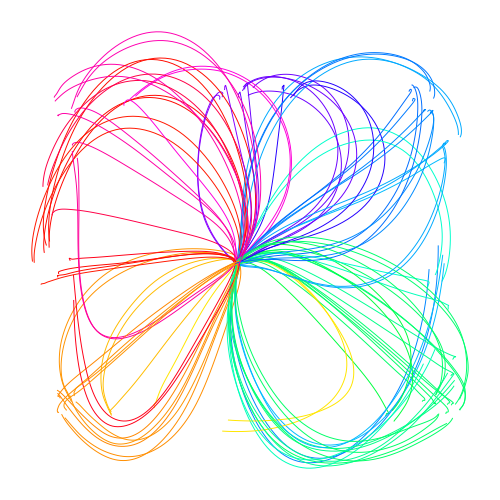

In [6]:
## Plot trial-averaged reaches

# Find unique conditions
conds = dataset.trial_info.set_index(['trial_type', 'trial_version']).index.unique().tolist()

# Initialize plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# Loop over conditions and compute average trajectory
for cond in conds:
    # Find trials in condition
    mask = np.all(dataset.trial_info[['trial_type', 'trial_version']] == cond, axis=1)
    # Extract trial data
    trial_data = dataset.make_trial_data(align_field='move_onset_time', align_range=(-50, 450), ignored_trials=(~mask))
    # Average hand position across trials
    traj = trial_data.groupby('align_time')[[('hand_pos', 'x'), ('hand_pos', 'y')]].mean().to_numpy()
    # Determine reach angle for color
    active_target = dataset.trial_info[mask].target_pos.iloc[0][dataset.trial_info[mask].active_target.iloc[0]]
    reach_angle = np.arctan2(*active_target[::-1])
    # Plot reach
    ax.plot(traj[:, 0], traj[:, 1], linewidth=0.7, color=plt.cm.hsv(reach_angle / (2*np.pi) + 0.5))

plt.axis('off')
plt.show()

## Preprocessing for FNO

In [7]:
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# 0. Smooth the spikes with a 50 ms standard deviation Gaussian kernel
dataset.smooth_spk(50, name='smth_50')

# 1. Extract neural data (input) and lagged hand velocity (target)
trial_data = dataset.make_trial_data(align_field='move_onset_time', align_range=(-130, 370))
lagged_trial_data = dataset.make_trial_data(align_field='move_onset_time', align_range=(-50, 450))

# Use bracket notation instead of dot notation for robust MultiIndex access
rates_2d = trial_data['spikes_smth_50'].to_numpy()
vel_2d = lagged_trial_data['hand_vel'].to_numpy()

# --- THE FIX: trial_id is just a normal column, not an index! ---
unique_trial_ids = trial_data['trial_id'].unique()

# 2. Compute tensor dimensions
# N = number of trials, T = number of time bins per trial, D = number of features
n_trials = len(unique_trial_ids)
n_time_bins = len(trial_data) // n_trials
n_units = rates_2d.shape[1]

# 3. Reshape into 3D tensors: (Batch, Time, Features)
rates_3d = rates_2d.reshape(n_trials, n_time_bins, n_units)
vel_3d = vel_2d.reshape(n_trials, n_time_bins, 2)

# 4. Define DataLoader preparation WITH IDS
def prepare_loaders_with_ids(X, y, ids, batch_size=32):
    # Split: 80% Train, 20% Temp 
    X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(
        X, y, ids, test_size=0.2, random_state=42
    )
    # Split Temp: 10% Val, 10% Test
    X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(
        X_temp, y_temp, ids_temp, test_size=0.5, random_state=42
    )

    # Convert to PyTorch DataLoaders
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)), 
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)), 
                            batch_size=batch_size)
    test_loader = DataLoader(TensorDataset(torch.Tensor(X_test), torch.Tensor(y_test)), 
                             batch_size=batch_size)
    
    return train_loader, val_loader, test_loader, ids_test

# Execute the updated function
train_loader, val_loader, test_loader, test_trial_ids = prepare_loaders_with_ids(rates_3d, vel_3d, unique_trial_ids)

print(f"Data reshaped successfully.")
print(f"Input shape (rates): {rates_3d.shape} -> (Trials, Time Bins, Neurons)")
print(f"Target shape (vel): {vel_3d.shape} -> (Trials, Time Bins, Kinematics)")
print(f"Test set isolated: {len(test_trial_ids)} trials with tracked IDs.")

/home/fis00gabripocc/miniconda3/envs/deeponet/lib/python3.10/site-packages/nlb_tools/nwb_interface.py:523: PerformanceWarning: indexing past lexsort depth may impact performance.
  trial_data = trial_data.merge(
/home/fis00gabripocc/miniconda3/envs/deeponet/lib/python3.10/site-packages/nlb_tools/nwb_interface.py:523: PerformanceWarning: indexing past lexsort depth may impact performance.
  trial_data = trial_data.merge(


Data reshaped successfully.
Input shape (rates): (2295, 100, 364) -> (Trials, Time Bins, Neurons)
Target shape (vel): (2295, 100, 2) -> (Trials, Time Bins, Kinematics)
Test set isolated: 230 trials with tracked IDs.


In [8]:
import torch

# ==========================================
# HARDWARE ACCELERATION SETUP
# ==========================================

if torch.cuda.is_available():
    device = torch.device('cuda')
    # Estrae il nome della GPU per conferma visiva
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU rilevata! L'addestramento sarà accelerato su: {gpu_name}")
    print(f"   Memoria allocata: {torch.cuda.memory_allocated(0)/(1024**3):.2f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ Nessuna GPU compatibile con CUDA rilevata.")
    print("   L'addestramento verrà eseguito sulla CPU. Le operazioni di FFT potrebbero risultare lente.")

# (Opzionale ma raccomandato per la riproducibilità scientifica)
# Fissiamo i seed per garantire la coerenza nei risultati tra diverse esecuzioni
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

✅ GPU rilevata! L'addestramento sarà accelerato su: Quadro RTX 5000
   Memoria allocata: 0.00 GB


In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import copy

# ==========================================
# 0. CLEANUP (Fixes the KeyError from previous runs)
# ==========================================
# If 'pred_vel' is lingering in the dataset from a previous run, it breaks nlb_tools.
# We remove it here before extracting the trials.
if 'pred_vel' in dataset.data.columns.get_level_values(0):
    dataset.data = dataset.data.drop(columns=['pred_vel'], level=0)

# ==========================================
# 1. DATA PREP & ROBUST 3D TENSOR CREATION
# ==========================================
dataset.smooth_spk(50, name='smth_50')

# Extract data 
trial_data = dataset.make_trial_data(align_field='move_onset_time', align_range=(-130, 370))
lagged_trial_data = dataset.make_trial_data(align_field='move_onset_time', align_range=(-50, 450))

# Group data by trial_id into dictionaries to handle variable lengths safely
rates_dict = {t_id: df['spikes_smth_50'].to_numpy() for t_id, df in trial_data.groupby('trial_id')}
vel_dict = {t_id: df['hand_vel'].to_numpy() for t_id, df in lagged_trial_data.groupby('trial_id')}
time_dict = {t_id: df['clock_time'].to_numpy() for t_id, df in lagged_trial_data.groupby('trial_id')}

# Ensure we only use trials present in both neural and kinematic sets
common_ids = sorted(list(set(rates_dict.keys()) & set(vel_dict.keys())))

# Find the absolute minimum number of time bins across all valid trials
min_bins = min(
    min(rates_dict[t_id].shape[0] for t_id in common_ids),
    min(vel_dict[t_id].shape[0] for t_id in common_ids)
)
print(f"Aligning all trials to {min_bins} time bins to fix length inconsistencies.")

# Truncate all trials to the exact same length and convert to lists
rates_list = [rates_dict[t_id][:min_bins, :] for t_id in common_ids]
vel_list = [vel_dict[t_id][:min_bins, :] for t_id in common_ids]
clock_time_list = [time_dict[t_id][:min_bins] for t_id in common_ids]

# Stack into perfectly rectangular 3D tensors: (N_trials, T_bins, D_features)
rates_3d = np.stack(rates_list)
vel_3d = np.stack(vel_list)
unique_trial_ids = np.array(common_ids)

# Save the exact clock times for accurate pandas reconstruction later
target_clock_times = np.concatenate(clock_time_list) 

n_trials, n_time_bins, n_units = rates_3d.shape

def prepare_loaders_with_ids(X, y, ids, batch_size=32):
    X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(
        X, y, ids, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(
        X_temp, y_temp, ids_temp, test_size=0.5, random_state=42)

    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)), batch_size=batch_size)
    test_loader = DataLoader(TensorDataset(torch.Tensor(X_test), torch.Tensor(y_test)), batch_size=batch_size)
    
    return train_loader, val_loader, test_loader, ids_test

train_loader, val_loader, test_loader, test_trial_ids = prepare_loaders_with_ids(rates_3d, vel_3d, unique_trial_ids)

print(f"Test set isolated: {len(test_trial_ids)} trials. Tensors shaped to (Trials: {n_trials}, TimeBins: {n_time_bins})")

# ==========================================
# 2. FNO ARCHITECTURE
# ==========================================
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super(SpectralConv1d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.scale = (1 / (in_channels * out_channels))
        self.weights = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes, dtype=torch.cfloat))

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft(x)
        out_ft = torch.zeros(batchsize, self.out_channels, x_ft.size(-1), device=x.device, dtype=torch.cfloat)
        out_ft[:, :, :self.modes] = torch.einsum("bix,iox->box", x_ft[:, :, :self.modes], self.weights)
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x

class FNO1d(nn.Module):
    def __init__(self, modes, width, input_dim, output_dim):
        super(FNO1d, self).__init__()
        self.modes = min(modes, n_time_bins // 2 + 1)
        self.width = width
        self.fc0 = nn.Linear(input_dim, self.width)
        self.conv0 = SpectralConv1d(self.width, self.width, self.modes)
        self.conv1 = SpectralConv1d(self.width, self.width, self.modes)
        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.fc0(x).permute(0, 2, 1)
        x = F.gelu(self.conv0(x) + self.w0(x))
        x = self.conv1(x) + self.w1(x)
        x = x.permute(0, 2, 1)
        x = F.gelu(self.fc1(x))
        return self.fc2(x)

# ==========================================
# 3. TRAINING & MODEL CHECKPOINTING
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FNO1d(modes=16, width=64, input_dim=n_units, output_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# --- LOSS FUNCTION SELECTION ---
loss_type = 'MSE' # Options: 'MSE', 'relative_L2', 'sobolev'
sobolev_alpha = 0.1 # Weight for the derivative penalty (only used if loss_type == 'sobolev')

class RelativeL2Loss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred, true):
        # Flatten time and feature dimensions for global norm calculation
        diff_norms = torch.linalg.norm(pred.reshape(pred.shape[0], -1) - true.reshape(true.shape[0], -1), 2, dim=1)
        true_norms = torch.linalg.norm(true.reshape(true.shape[0], -1), 2, dim=1)
        return torch.mean(diff_norms / true_norms)

class SobolevLoss1D(nn.Module):
    def __init__(self, alpha=0.1):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
    def forward(self, pred, true):
        # L2 error (MSE)
        loss_l2 = self.mse(pred, true)
        # H1 error (derivatives evaluated via finite differences along the temporal dimension)
        pred_diff = torch.diff(pred, dim=1)
        true_diff = torch.diff(true, dim=1)
        loss_h1 = self.mse(pred_diff, true_diff)
        return loss_l2 + self.alpha * loss_h1

if loss_type == 'MSE':
    criterion = nn.MSELoss()
elif loss_type == 'relative_L2':
    criterion = RelativeL2Loss()
elif loss_type == 'sobolev':
    criterion = SobolevLoss1D(alpha=sobolev_alpha)
else:
    raise ValueError("Invalid loss_type. Choose 'MSE', 'relative_L2', or 'sobolev'.")
# -------------------------------

epochs = 1000 
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_weights = None
best_epoch = 0

pbar = tqdm(range(epochs), desc=f"Training FNO (Loss: {loss_type})")

for epoch in pbar:
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            out_val = model(x_val)
            v_loss = criterion(out_val, y_val)
            val_loss += v_loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # --- Save the best model ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        best_model_weights = copy.deepcopy(model.state_dict())
    
    pbar.set_postfix({
        'Train Loss': f"{avg_train_loss:.4f}", 
        'Val Loss': f"{avg_val_loss:.4f}",
        'Best Val': f"{best_val_loss:.4f}"
    })

# ==========================================
# 4. FINAL INFERENCE WITH THE BEST MODEL
# ==========================================
print(f"\nLoading optimal weights (Epoch {best_epoch}) with Validation Loss: {best_val_loss:.4f}")
model.load_state_dict(best_model_weights)

print("Training completed. The best model is loaded in memory and ready for plotting/evaluation.")

/home/fis00gabripocc/miniconda3/envs/deeponet/lib/python3.10/site-packages/nlb_tools/nwb_interface.py:523: PerformanceWarning: indexing past lexsort depth may impact performance.
  trial_data = trial_data.merge(
/home/fis00gabripocc/miniconda3/envs/deeponet/lib/python3.10/site-packages/nlb_tools/nwb_interface.py:523: PerformanceWarning: indexing past lexsort depth may impact performance.
  trial_data = trial_data.merge(


Aligning all trials to 100 time bins to fix length inconsistencies.
Test set isolated: 230 trials. Tensors shaped to (Trials: 2295, TimeBins: 100)


Training FNO (Loss: MSE):   0%|          | 0/1000 [00:00<?, ?it/s]


Loading optimal weights (Epoch 78) with Validation Loss: 8753.4860
Training completed. The best model is loaded in memory and ready for plotting/evaluation.


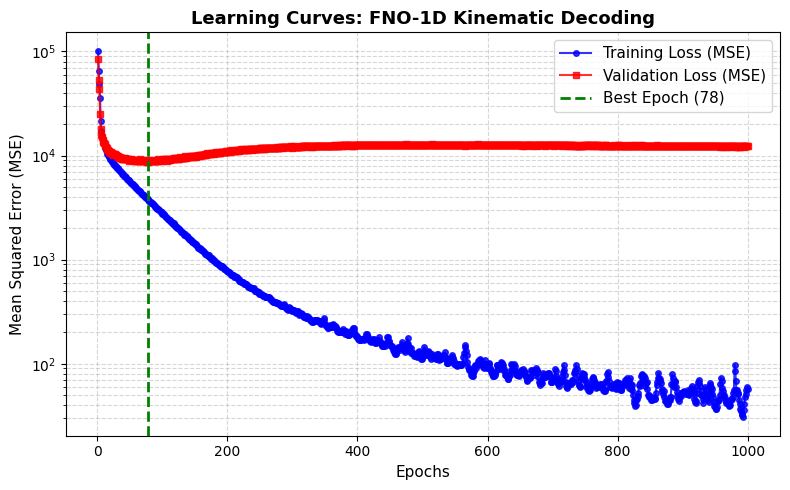

In [10]:
import matplotlib.pyplot as plt

# Initialize the figure
fig, ax = plt.subplots(figsize=(8, 5))

# Extract the x-axis (epochs from 1 to N)
epoch_axis = range(1, epochs + 1)

# Plot the learning curves
ax.plot(epoch_axis, train_losses, label='Training Loss (MSE)', marker='o', markersize=4, color='blue', alpha=0.8)
ax.plot(epoch_axis, val_losses, label='Validation Loss (MSE)', marker='s', markersize=4, color='red', alpha=0.8)

# Highlight the best epoch with a vertical dashed line
# 'best_epoch' was computed and saved in the previous training cell
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')

# Rigorous formatting for scientific analysis
ax.set_title('Learning Curves: FNO-1D Kinematic Decoding', fontsize=13, fontweight='bold')
ax.set_xlabel('Epochs', fontsize=11)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=11)

# Logarithmic scale (standard practice to observe convergence in Operator Learning and PINNs)
ax.set_yscale('log')

# Add grid and legend
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

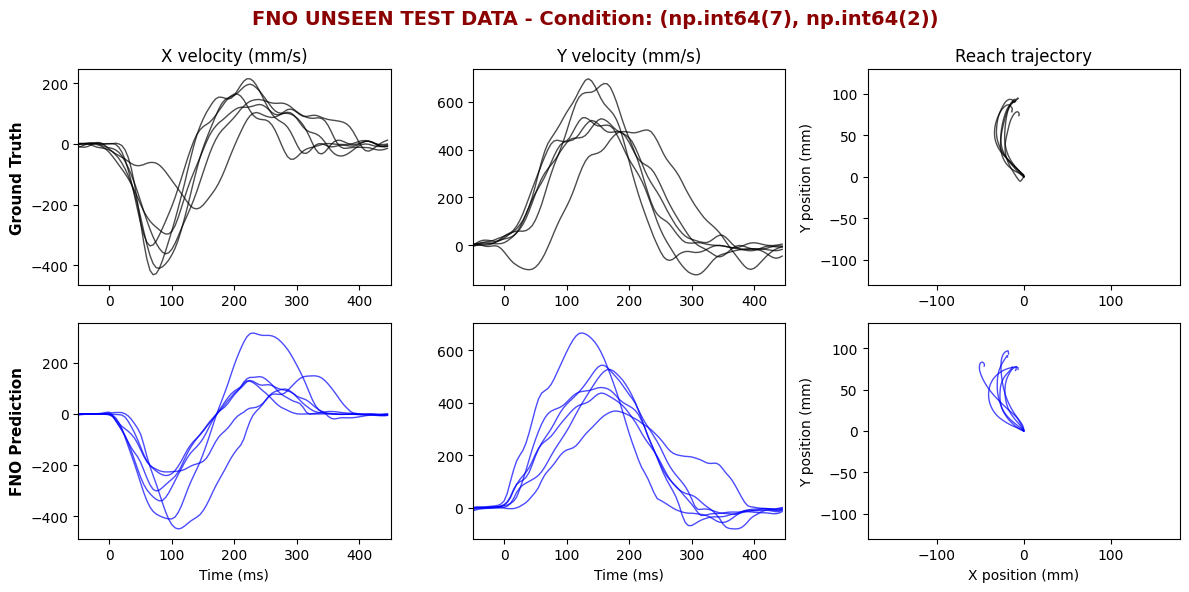

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select a condition present in the test set
test_info = dataset.trial_info.loc[test_trial_ids]
most_frequent_cond = test_info.value_counts(['trial_type', 'trial_version']).index[0]
cond = most_frequent_cond

# 2. Find which test_trial_ids belong to this specific condition
# 'cond' is a tuple like (trial_type, trial_version)
cond_trials_in_test = test_info[
    (test_info['trial_type'] == cond[0]) & 
    (test_info['trial_version'] == cond[1])
].index.tolist()

# 3. Initialize the figure
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle(f'FNO UNSEEN TEST DATA - Condition: {cond}', fontsize=14, fontweight='bold', color='darkred')

# 4. We will use the model directly to predict on the test trials.
# We already have unique_trial_ids from training. We find the tensor indices for our chosen test trials.
t_dynamic = np.linspace(-50, 450, n_time_bins, endpoint=False)
dt_seconds = (500.0 / n_time_bins) / 1000.0

model.eval()
with torch.no_grad():
    for t_id in cond_trials_in_test:
        # Find the index of this trial in the original 3D tensors
        idx = np.where(unique_trial_ids == t_id)[0][0]
        
        # Extract Ground Truth from the 3D tensor
        true_v = vel_3d[idx] 
        true_vx = true_v[:, 0]
        true_vy = true_v[:, 1]
        
        # Extract Input Rates and predict with the FNO
        rates_input = torch.Tensor(rates_3d[idx:idx+1]).to(device) # Shape: (1, Time, Neurons)
        pred_v = model(rates_input).cpu().numpy()[0]
        pred_vx = pred_v[:, 0]
        pred_vy = pred_v[:, 1]
        
        # Plot X velocity
        axs[0][0].plot(t_dynamic, true_vx, linewidth=1, color='black', alpha=0.7)
        axs[1][0].plot(t_dynamic, pred_vx, linewidth=1, color='blue', alpha=0.7)
        
        # Plot Y velocity
        axs[0][1].plot(t_dynamic, true_vy, linewidth=1, color='black', alpha=0.7)
        axs[1][1].plot(t_dynamic, pred_vy, linewidth=1, color='blue', alpha=0.7)
        
        # Integrate velocities to compute physical trajectories
        true_traj = np.cumsum(true_v, axis=0) * dt_seconds
        pred_traj = np.cumsum(pred_v, axis=0) * dt_seconds
        
        # Plot spatial trajectories
        axs[0][2].plot(true_traj[:, 0], true_traj[:, 1], linewidth=1, color='black', alpha=0.7)
        axs[1][2].plot(pred_traj[:, 0], pred_traj[:, 1], linewidth=1, color='blue', alpha=0.7)

# 5. Format the axes
for i in range(2):
    axs[i][0].set_xlim(-50, 450)
    axs[i][1].set_xlim(-50, 450)
    axs[i][2].set_xlim(-180, 180)
    axs[i][2].set_ylim(-130, 130)
    axs[i][0].set_ylabel('Ground Truth' if i == 0 else 'FNO Prediction', fontweight='bold', fontsize=11)

axs[0][0].set_title('X velocity (mm/s)')
axs[0][1].set_title('Y velocity (mm/s)')
axs[0][2].set_title('Reach trajectory')

axs[1][0].set_xlabel('Time (ms)')
axs[1][1].set_xlabel('Time (ms)')
axs[1][2].set_xlabel('X position (mm)')
axs[0][2].set_ylabel('Y position (mm)')
axs[1][2].set_ylabel('Y position (mm)')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Generating nested grid plot for 3 condition(s) using FNO.


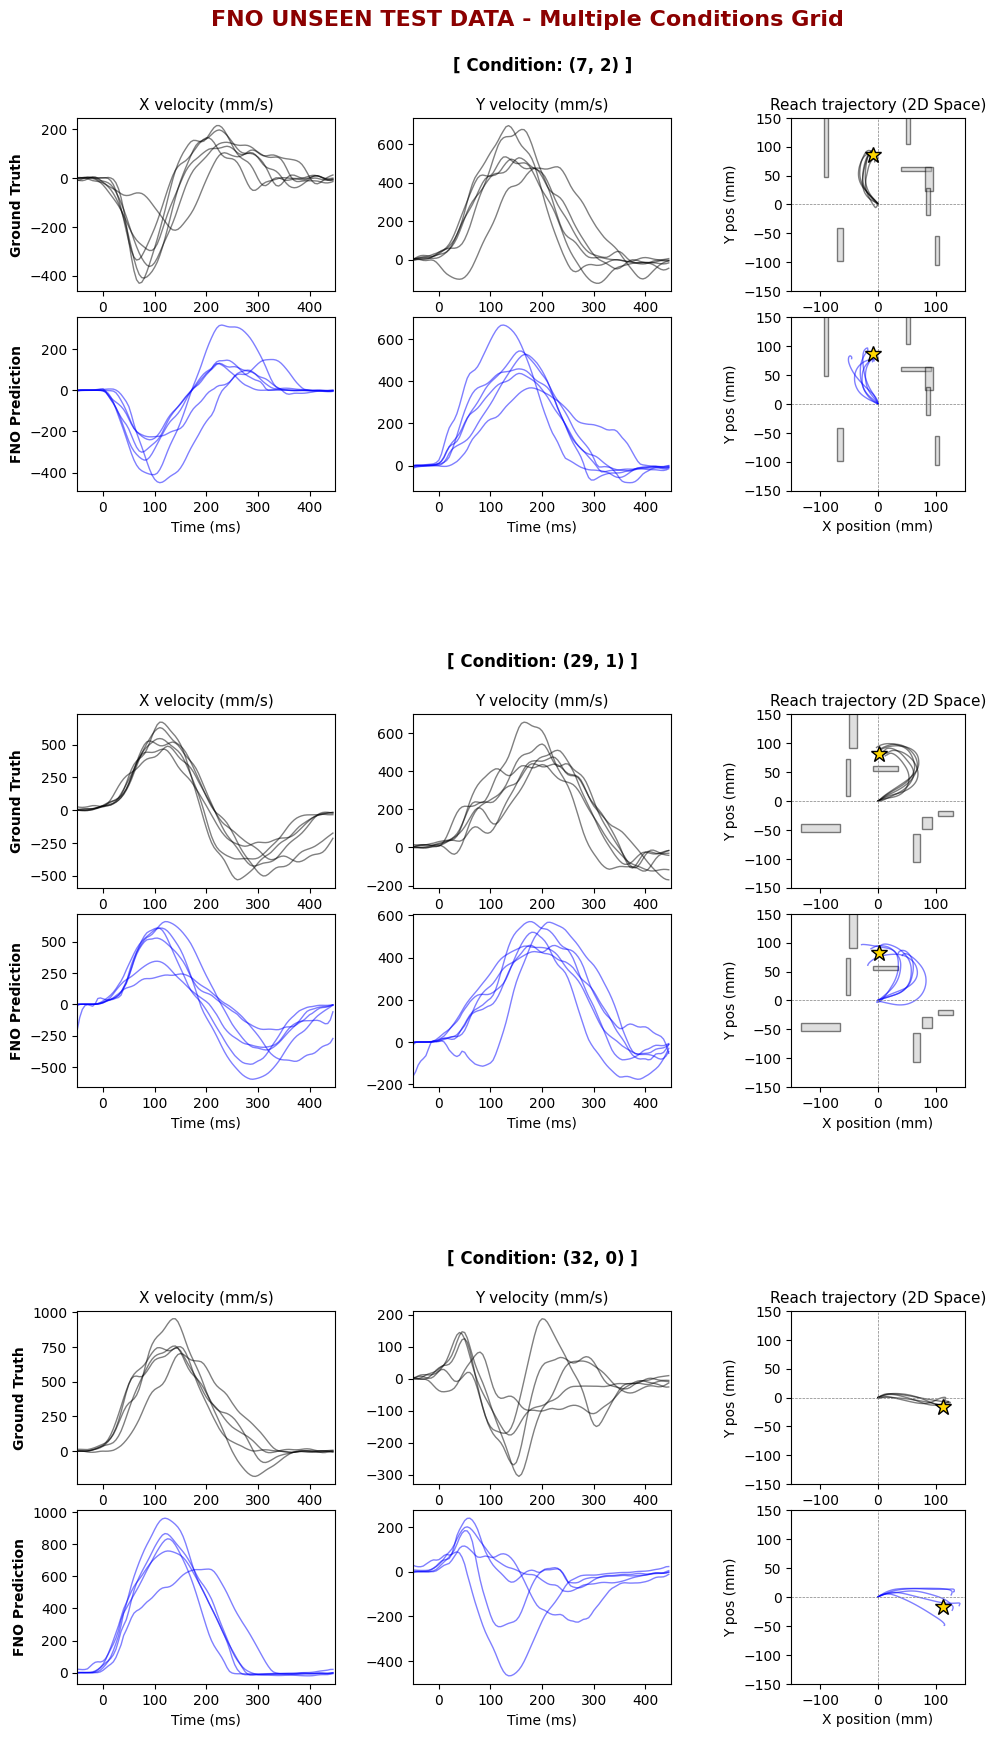

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
import torch

# ==========================================
# FNO VISUALIZATION: KINEMATIC GRID PLOT
# ==========================================

# 1. Identify conditions using the globally available test_trial_ids
test_info = dataset.trial_info.loc[test_trial_ids]
available_conds = test_info.value_counts(['trial_type', 'trial_version']).index.tolist()

# Define the indices of the conditions you want to plot
condition_indices = [0, 1, 2]  
valid_indices = [idx for idx in condition_indices if idx < len(available_conds)]

if not valid_indices:
    print("Error: All provided indices are out of bounds.")
else:
    n_conds = len(valid_indices)
    print(f"Generating nested grid plot for {n_conds} condition(s) using FNO.")

    fig = plt.figure(figsize=(12, 6 * n_conds))
    fig.suptitle('FNO UNSEEN TEST DATA - Multiple Conditions Grid', 
                 fontsize=16, fontweight='bold', color='darkred', y=0.98)

    outer_gs = gridspec.GridSpec(n_conds, 1, figure=fig, hspace=0.6, top=0.92, bottom=0.05)

    t_dynamic = np.linspace(-50, 450, n_time_bins, endpoint=False)
    dt_seconds = (500.0 / n_time_bins) / 1000.0

    model.eval()
    with torch.no_grad():
        for i, c_idx in enumerate(valid_indices):
            cond = available_conds[c_idx]
            
            inner_gs = outer_gs[i].subgridspec(2, 3, hspace=0.15, wspace=0.3)
            axs = np.empty((2, 3), dtype=object)
            for r in range(2):
                for c in range(3):
                    axs[r, c] = fig.add_subplot(inner_gs[r, c])
            
            cond_trials_in_test = test_info[
                (test_info['trial_type'] == cond[0]) & 
                (test_info['trial_version'] == cond[1])
            ].index.tolist()

            # --- NEW: Extract first trial info for maze geometry ---
            first_trial_info = test_info.loc[cond_trials_in_test[0]]
            
            # --- NEW: Draw Maze and Target on the Spatial Plots (Column 2) ---
            for r in range(2):
                if 'barrier_pos' in first_trial_info and first_trial_info['barrier_pos'] is not None:
                    for barrier in first_trial_info['barrier_pos']:
                        # Format is [x_bottom_left, y_bottom_left, width, height]
                        x_bl, y_bl, w, h = barrier
                        rect = patches.Rectangle((x_bl, y_bl), w, h, 
                                                 linewidth=1, edgecolor='black', facecolor='silver', alpha=0.5)
                        axs[r, 2].add_patch(rect)
                
                if 'target_pos' in first_trial_info and first_trial_info['target_pos'] is not None:
                    active_target_idx = first_trial_info['active_target']
                    target = first_trial_info['target_pos'][active_target_idx]
                    axs[r, 2].plot(target[0], target[1], marker='*', markersize=12, color='gold', markeredgecolor='black', zorder=10)

            # Loop trials and plot trajectories
            for t_id in cond_trials_in_test:
                # Find the index safely using the globally tracked unique_trial_ids
                idx = np.where(unique_trial_ids == t_id)[0][0]
                
                true_v = vel_3d[idx] 
                true_vx = true_v[:, 0]
                true_vy = true_v[:, 1]
                
                rates_input = torch.Tensor(rates_3d[idx:idx+1]).to(device)
                
                # --- FNO INFERENCE ---
                pred_v = model(rates_input).cpu().numpy()[0]
                pred_vx = pred_v[:, 0]
                pred_vy = pred_v[:, 1]
                
                axs[0, 0].plot(t_dynamic, true_vx, linewidth=1, color='black', alpha=0.5)
                axs[1, 0].plot(t_dynamic, pred_vx, linewidth=1, color='blue', alpha=0.5)
                
                axs[0, 1].plot(t_dynamic, true_vy, linewidth=1, color='black', alpha=0.5)
                axs[1, 1].plot(t_dynamic, pred_vy, linewidth=1, color='blue', alpha=0.5)
                
                true_traj = np.cumsum(true_v, axis=0) * dt_seconds
                pred_traj = np.cumsum(pred_v, axis=0) * dt_seconds
                
                axs[0, 2].plot(true_traj[:, 0], true_traj[:, 1], linewidth=1, color='black', alpha=0.5)
                axs[1, 2].plot(pred_traj[:, 0], pred_traj[:, 1], linewidth=1, color='blue', alpha=0.5)

            # Formatting
            for r in range(2):
                axs[r, 0].set_xlim(-50, 450)
                axs[r, 1].set_xlim(-50, 450)
                
                axs[r, 2].set_xlim(-150, 150)
                axs[r, 2].set_ylim(-150, 150)
                axs[r, 2].axhline(0, color='grey', linestyle='--', linewidth=0.5)
                axs[r, 2].axvline(0, color='grey', linestyle='--', linewidth=0.5)
                
                # Make sure the maze doesn't get distorted
                axs[r, 2].set_aspect('equal') 
                
                if r == 0:
                    axs[r, 0].set_ylabel('Ground Truth', fontweight='bold', fontsize=10)
                else:
                    axs[r, 0].set_ylabel('FNO Prediction', fontweight='bold', fontsize=10)

            # Titles
            axs[0, 1].annotate(f'[ Condition: {cond} ]', xy=(0.5, 1.25), 
                               xycoords='axes fraction', ha='center', va='bottom', 
                               fontsize=12, fontweight='bold')
            
            axs[0, 0].set_title('X velocity (mm/s)', fontsize=11, fontweight='normal')
            axs[0, 1].set_title('Y velocity (mm/s)', fontsize=11, fontweight='normal')
            axs[0, 2].set_title('Reach trajectory (2D Space)', fontsize=11, fontweight='normal')

            axs[1, 0].set_xlabel('Time (ms)')
            axs[1, 1].set_xlabel('Time (ms)')
            axs[1, 2].set_xlabel('X position (mm)')
            
            axs[0, 2].set_ylabel('Y pos (mm)')
            axs[1, 2].set_ylabel('Y pos (mm)')

    plt.show()

=== FNO Test Set Evaluation ===
Total Test Trials: 230
Training Loss (MSE): 8271.5508 ± 5865.9590
Relative L2 Error:       0.2846 ± 0.0926
Median Rel L2 Error:     0.2720



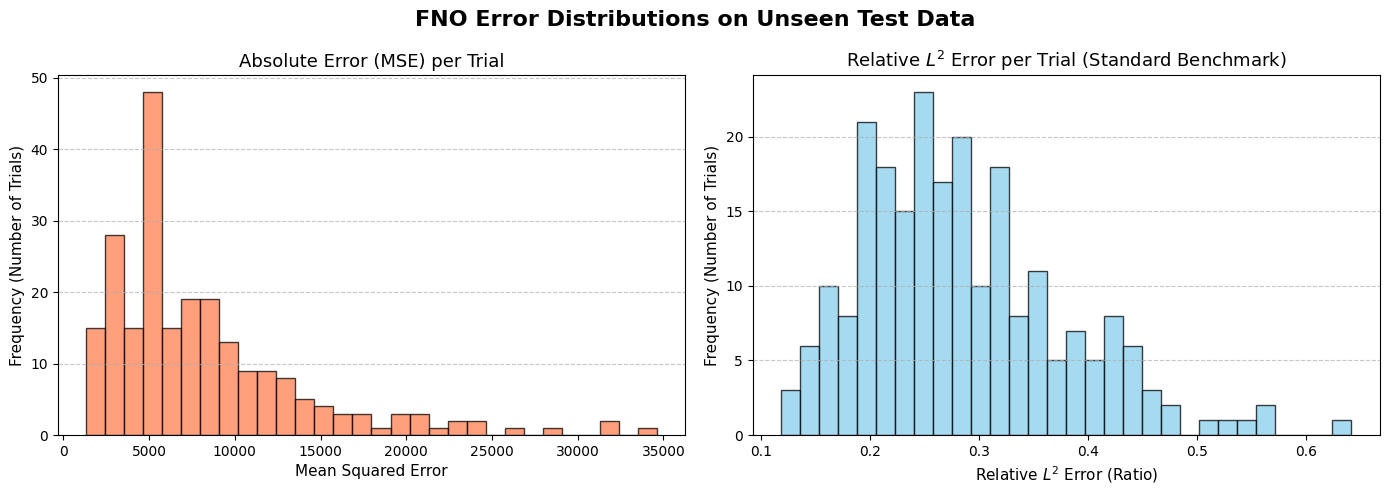

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 5. QUANTITATIVE EVALUATION ON TEST SET
# ==========================================

# Ensure the model is in evaluation mode
model.eval()

# Lists to store the errors for each individual trial
primary_errors = []
rel_l2_errors = []

# Disable gradient computation for inference
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass: predict kinematics from neural rates
        predictions = model(x_batch)
        
        # --- 1. ALWAYS CALCULATE RELATIVE L2 ERROR (Standard Benchmark) ---
        diff_norm = torch.linalg.norm((predictions - y_batch).reshape(x_batch.shape[0], -1), dim=1)
        true_norm = torch.linalg.norm(y_batch.reshape(y_batch.shape[0], -1), dim=1)
        rel_l2_per_trial = diff_norm / true_norm
        
        rel_l2_errors.extend(rel_l2_per_trial.cpu().numpy())
        
        # --- 2. CALCULATE THE SELECTED TRAINING LOSS PER TRIAL ---
        if loss_type == 'MSE':
            err_per_trial = torch.mean((predictions - y_batch)**2, dim=[1, 2])
            
        elif loss_type == 'relative_L2':
            err_per_trial = rel_l2_per_trial # Same as above
            
        elif loss_type == 'sobolev':
            # MSE component
            mse_per_trial = torch.mean((predictions - y_batch)**2, dim=[1, 2])
            # H1 component (temporal derivatives)
            pred_diff = torch.diff(predictions, dim=1)
            true_diff = torch.diff(y_batch, dim=1)
            h1_per_trial = torch.mean((pred_diff - true_diff)**2, dim=[1, 2])
            # Combine based on alpha
            err_per_trial = mse_per_trial + sobolev_alpha * h1_per_trial
            
        primary_errors.extend(err_per_trial.cpu().numpy())

# Convert lists to numpy arrays for statistical operations
primary_errors = np.array(primary_errors)
rel_l2_errors = np.array(rel_l2_errors)

# Print Summary Statistics
print("=== FNO Test Set Evaluation ===")
print(f"Total Test Trials: {len(primary_errors)}")
print(f"Training Loss ({loss_type}): {np.mean(primary_errors):.4f} ± {np.std(primary_errors):.4f}")

# Only print L2 separately if it wasn't the main training loss
if loss_type != 'relative_L2':
    print(f"Relative L2 Error:       {np.mean(rel_l2_errors):.4f} ± {np.std(rel_l2_errors):.4f}")

print(f"Median Rel L2 Error:     {np.median(rel_l2_errors):.4f}")
print("===============================\n")

# ==========================================
# PLOT ERROR DISTRIBUTIONS (HISTOGRAMS)
# ==========================================
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FNO Error Distributions on Unseen Test Data', fontsize=16, fontweight='bold')

# Plot 1: Primary Selected Loss Histogram
axs[0].hist(primary_errors, bins=30, color='coral', edgecolor='black', alpha=0.75)

# Dynamically set titles and labels based on the chosen loss type
if loss_type == 'MSE':
    axs[0].set_title('Absolute Error (MSE) per Trial', fontsize=13)
    axs[0].set_xlabel('Mean Squared Error', fontsize=11)
elif loss_type == 'relative_L2':
    axs[0].set_title('Relative $L^2$ Error (Training Objective)', fontsize=13)
    axs[0].set_xlabel('Relative $L^2$ Error (Ratio)', fontsize=11)
elif loss_type == 'sobolev':
    axs[0].set_title(f'Sobolev Error ($\\alpha$={sobolev_alpha}) per Trial', fontsize=13)
    axs[0].set_xlabel('Sobolev Loss', fontsize=11)

axs[0].set_ylabel('Frequency (Number of Trials)', fontsize=11)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Relative L2 Error Histogram (Always standard)
axs[1].hist(rel_l2_errors, bins=30, color='skyblue', edgecolor='black', alpha=0.75)
axs[1].set_title('Relative $L^2$ Error per Trial (Standard Benchmark)', fontsize=13)
axs[1].set_xlabel('Relative $L^2$ Error (Ratio)', fontsize=11)
axs[1].set_ylabel('Frequency (Number of Trials)', fontsize=11)
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

In [14]:
from sklearn.metrics import r2_score
import torch
import numpy as np

# ==========================================
# 6. R-SQUARED (R2) SCORE ON TEST SET
# ==========================================

# Ensure the model is in evaluation mode
model.eval()

# Lists to collect flattened true and predicted values across all test batches
all_true_vel = []
all_pred_vel = []

# Disable gradient computation for inference
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass: predict kinematics
        predictions = model(x_batch)
        
        # Flatten from 3D (Batch, Time, 2) to 2D (Batch * Time, 2)
        # This explicitly matches the shape evaluated by the Ridge Regression baseline
        pred_flat = predictions.reshape(-1, 2).cpu().numpy()
        true_flat = y_batch.reshape(-1, 2).cpu().numpy()
        
        all_pred_vel.append(pred_flat)
        all_true_vel.append(true_flat)

# Concatenate all batches into single numpy arrays
all_pred_vel = np.vstack(all_pred_vel)
all_true_vel = np.vstack(all_true_vel)

# Calculate R2 score using scikit-learn
# We compute it for X and Y separately to see if one axis is harder to decode
r2_x = r2_score(all_true_vel[:, 0], all_pred_vel[:, 0])
r2_y = r2_score(all_true_vel[:, 1], all_pred_vel[:, 1])

# Calculate the global (variance-weighted) R2 score across both dimensions
r2_global = r2_score(all_true_vel, all_pred_vel)

print("=== FNO R-squared (R2) Evaluation on Unseen Test Set ===")
print(f"Global R2 Score: {r2_global:.4f}")
print(f"X Velocity R2:   {r2_x:.4f}")
print(f"Y Velocity R2:   {r2_y:.4f}")
print("========================================================")

=== FNO R-squared (R2) Evaluation on Unseen Test Set ===
Global R2 Score: 0.9132
X Velocity R2:   0.9293
Y Velocity R2:   0.8971


## Benchamrk: LSTM
We now compare our results with a normal (non operator network) LSTM network

In [23]:
# ==========================================
# 7. STANDALONE LSTM BENCHMARK ARCHITECTURE & TRAINING
# ==========================================
import torch
import torch.nn as nn
import copy
from tqdm.auto import tqdm

# --- 1. HARDWARE SETUP ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 2. LOSS FUNCTION DEFINITION ---
loss_type = 'MSE' # Options: 'MSE', 'relative_L2', 'sobolev'
sobolev_alpha = 0.1 

class RelativeL2Loss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred, true):
        diff_norms = torch.linalg.norm(pred.reshape(pred.shape[0], -1) - true.reshape(true.shape[0], -1), 2, dim=1)
        true_norms = torch.linalg.norm(true.reshape(true.shape[0], -1), 2, dim=1)
        return torch.mean(diff_norms / true_norms)

class SobolevLoss1D(nn.Module):
    def __init__(self, alpha=0.1):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
    def forward(self, pred, true):
        loss_l2 = self.mse(pred, true)
        pred_diff = torch.diff(pred, dim=1)
        true_diff = torch.diff(true, dim=1)
        loss_h1 = self.mse(pred_diff, true_diff)
        return loss_l2 + self.alpha * loss_h1

if loss_type == 'MSE':
    criterion = nn.MSELoss()
elif loss_type == 'relative_L2':
    criterion = RelativeL2Loss()
elif loss_type == 'sobolev':
    criterion = SobolevLoss1D(alpha=sobolev_alpha)
else:
    raise ValueError("Invalid loss_type. Choose 'MSE', 'relative_L2', or 'sobolev'.")

# --- 3. LSTM ARCHITECTURE ---
class KinematicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=2):
        super(KinematicLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # batch_first=True matches (Batch, Time, Features)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=0.2 if num_layers > 1 else 0.0)
        
        # Linear readout to map hidden states to (x, y) velocity
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out)
        return out

# --- 4. INITIALIZATION & TRAINING LOOP ---
lstm_model = KinematicLSTM(input_dim=n_units, hidden_dim=64, num_layers=2, output_dim=2).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)

lstm_epochs = 1000 
lstm_train_losses = []
lstm_val_losses = []

lstm_best_val_loss = float('inf')
lstm_best_weights = None
lstm_best_epoch = 0

print(f"Training LSTM using loss function: {loss_type}")
pbar_lstm = tqdm(range(lstm_epochs), desc="Training LSTM")

for epoch in pbar_lstm:
    # --- Training Phase ---
    lstm_model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        lstm_optimizer.zero_grad()
        out = lstm_model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        lstm_optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    lstm_train_losses.append(avg_train_loss)
    
    # --- Validation Phase ---
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            out_val = lstm_model(x_val)
            v_loss = criterion(out_val, y_val)
            val_loss += v_loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    lstm_val_losses.append(avg_val_loss)
    
    # --- Save the best model ---
    if avg_val_loss < lstm_best_val_loss:
        lstm_best_val_loss = avg_val_loss
        lstm_best_epoch = epoch + 1
        lstm_best_weights = copy.deepcopy(lstm_model.state_dict())
    
    pbar_lstm.set_postfix({
        'Train Loss': f"{avg_train_loss:.4f}", 
        'Val Loss': f"{avg_val_loss:.4f}",
        'Best Val': f"{lstm_best_val_loss:.4f}"
    })

# --- 5. LOAD BEST MODEL ---
print(f"\nLoading optimal LSTM weights (Epoch {lstm_best_epoch}) with Val Loss: {lstm_best_val_loss:.4f}")
lstm_model.load_state_dict(lstm_best_weights)
lstm_model.eval()
print("LSTM Training complete and ready for inference.")

Using device: cuda
Training LSTM using loss function: MSE


Training LSTM:   0%|          | 0/1000 [00:00<?, ?it/s]


Loading optimal LSTM weights (Epoch 382) with Val Loss: 11333.0630
LSTM Training complete and ready for inference.


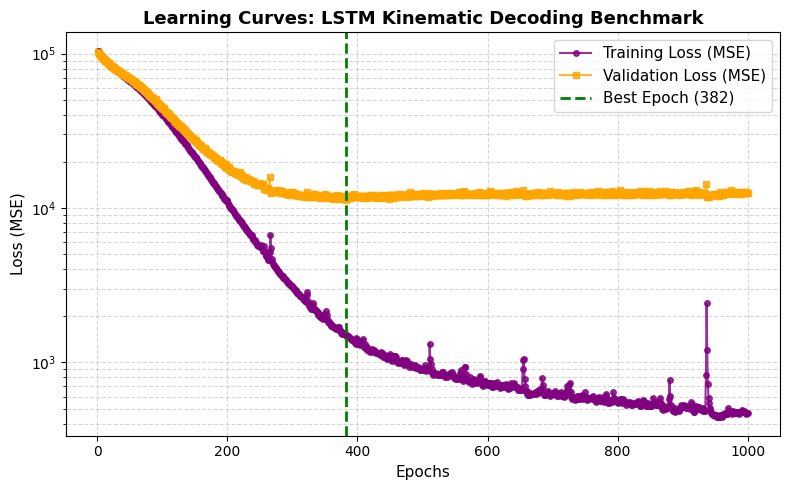

In [24]:
import matplotlib.pyplot as plt

# ==========================================
# 8. PLOT LSTM LEARNING CURVES
# ==========================================

fig, ax = plt.subplots(figsize=(8, 5))
lstm_epoch_axis = range(1, lstm_epochs + 1)

ax.plot(lstm_epoch_axis, lstm_train_losses, label=f'Training Loss ({loss_type})', 
        marker='o', markersize=4, color='purple', alpha=0.8)
ax.plot(lstm_epoch_axis, lstm_val_losses, label=f'Validation Loss ({loss_type})', 
        marker='s', markersize=4, color='orange', alpha=0.8)

ax.axvline(x=lstm_best_epoch, color='green', linestyle='--', linewidth=2, 
           label=f'Best Epoch ({lstm_best_epoch})')

ax.set_title('Learning Curves: LSTM Kinematic Decoding Benchmark', fontsize=13, fontweight='bold')
ax.set_xlabel('Epochs', fontsize=11)
ax.set_ylabel(f'Loss ({loss_type})', fontsize=11)
ax.set_yscale('log')

ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

=== LSTM BENCHMARK TEST SET RESULTS ===
Global R2 Score:       0.8778
X Velocity R2:         0.8976
Y Velocity R2:         0.8580
Training Loss (MSE): 11672.3848 ± 8768.8965
Relative L2 Error:     0.3362 ± 0.1272
Median Rel L2 Error:   0.3089



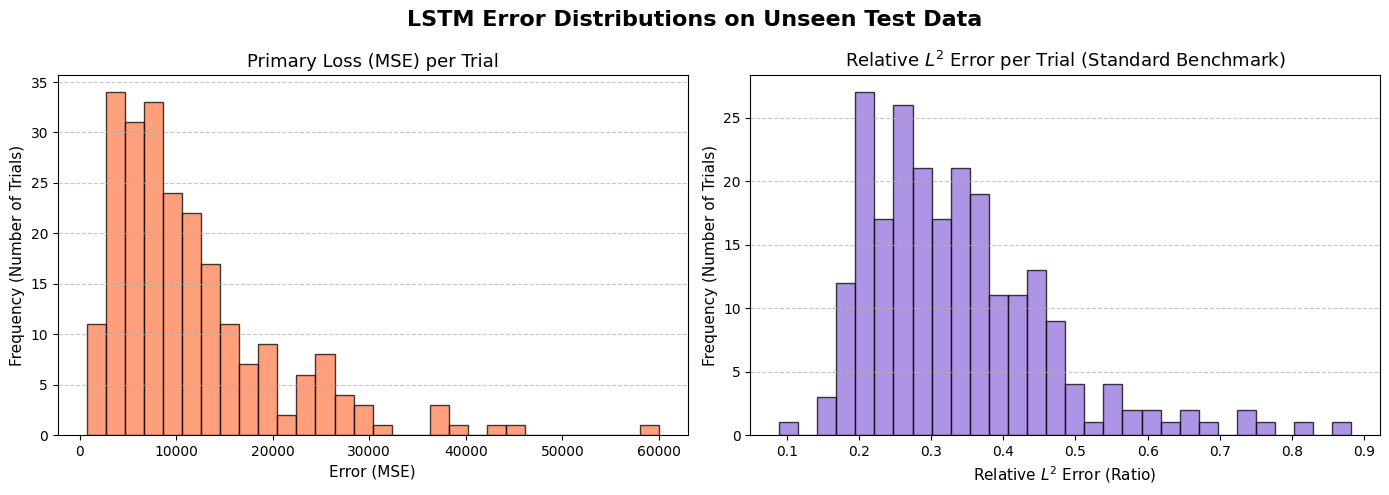

In [25]:
from sklearn.metrics import r2_score
import numpy as np

# ==========================================
# 9. LSTM QUANTITATIVE EVALUATION (R2 & L2)
# ==========================================

lstm_model.eval()

lstm_primary_errors = []
lstm_rel_l2_errors = []
lstm_all_true_vel = []
lstm_all_pred_vel = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        predictions = lstm_model(x_batch)
        
        # --- Relative L2 Error ---
        diff_norm = torch.linalg.norm((predictions - y_batch).reshape(x_batch.shape[0], -1), dim=1)
        true_norm = torch.linalg.norm(y_batch.reshape(y_batch.shape[0], -1), dim=1)
        rel_l2_per_trial = diff_norm / true_norm
        lstm_rel_l2_errors.extend(rel_l2_per_trial.cpu().numpy())
        
        # --- Primary Loss (based on selection) ---
        if loss_type == 'MSE':
            err_per_trial = torch.mean((predictions - y_batch)**2, dim=[1, 2])
        elif loss_type == 'relative_L2':
            err_per_trial = rel_l2_per_trial
        elif loss_type == 'sobolev':
            mse_per_trial = torch.mean((predictions - y_batch)**2, dim=[1, 2])
            pred_diff = torch.diff(predictions, dim=1)
            true_diff = torch.diff(y_batch, dim=1)
            h1_per_trial = torch.mean((pred_diff - true_diff)**2, dim=[1, 2])
            err_per_trial = mse_per_trial + sobolev_alpha * h1_per_trial
            
        lstm_primary_errors.extend(err_per_trial.cpu().numpy())
        
        # --- For R2 Score ---
        lstm_all_pred_vel.append(predictions.reshape(-1, 2).cpu().numpy())
        lstm_all_true_vel.append(y_batch.reshape(-1, 2).cpu().numpy())

lstm_primary_errors = np.array(lstm_primary_errors)
lstm_rel_l2_errors = np.array(lstm_rel_l2_errors)
lstm_all_pred_vel = np.vstack(lstm_all_pred_vel)
lstm_all_true_vel = np.vstack(lstm_all_true_vel)

lstm_r2_x = r2_score(lstm_all_true_vel[:, 0], lstm_all_pred_vel[:, 0])
lstm_r2_y = r2_score(lstm_all_true_vel[:, 1], lstm_all_pred_vel[:, 1])
lstm_r2_global = r2_score(lstm_all_true_vel, lstm_all_pred_vel)

print("=== LSTM BENCHMARK TEST SET RESULTS ===")
print(f"Global R2 Score:       {lstm_r2_global:.4f}")
print(f"X Velocity R2:         {lstm_r2_x:.4f}")
print(f"Y Velocity R2:         {lstm_r2_y:.4f}")
print(f"Training Loss ({loss_type}): {np.mean(lstm_primary_errors):.4f} ± {np.std(lstm_primary_errors):.4f}")
if loss_type != 'relative_L2':
    print(f"Relative L2 Error:     {np.mean(lstm_rel_l2_errors):.4f} ± {np.std(lstm_rel_l2_errors):.4f}")
print(f"Median Rel L2 Error:   {np.median(lstm_rel_l2_errors):.4f}")
print("=======================================\n")

# --- Plot Error Histograms ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Error Distributions on Unseen Test Data', fontsize=16, fontweight='bold')

axs[0].hist(lstm_primary_errors, bins=30, color='coral', edgecolor='black', alpha=0.75)
axs[0].set_title(f'Primary Loss ({loss_type}) per Trial', fontsize=13)
axs[0].set_xlabel(f'Error ({loss_type})', fontsize=11)
axs[0].set_ylabel('Frequency (Number of Trials)', fontsize=11)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

axs[1].hist(lstm_rel_l2_errors, bins=30, color='mediumpurple', edgecolor='black', alpha=0.75)
axs[1].set_title('Relative $L^2$ Error per Trial (Standard Benchmark)', fontsize=13)
axs[1].set_xlabel('Relative $L^2$ Error (Ratio)', fontsize=11)
axs[1].set_ylabel('Frequency (Number of Trials)', fontsize=11)
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

Generating nested grid plot for 3 condition(s) using LSTM.


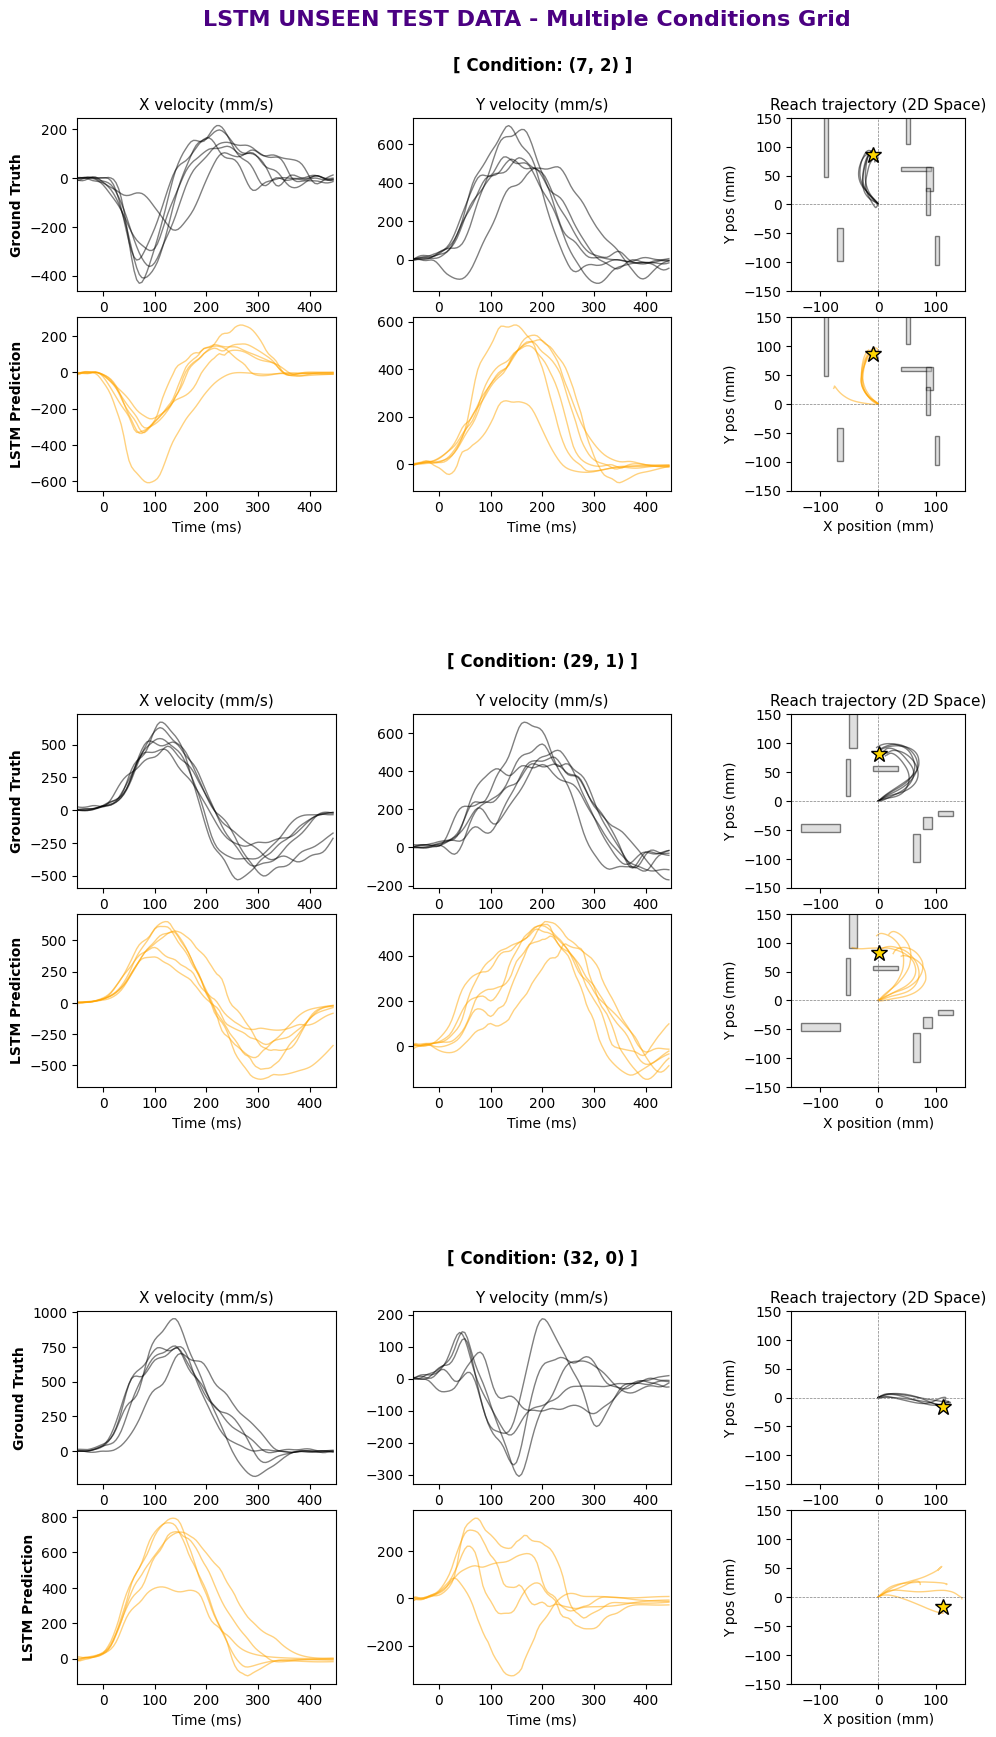

In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
import torch

# ==========================================
# LSTM VISUALIZATION: KINEMATIC GRID PLOT
# ==========================================

# 1. Identify conditions using the globally available test_trial_ids
test_info = dataset.trial_info.loc[test_trial_ids]
available_conds = test_info.value_counts(['trial_type', 'trial_version']).index.tolist()

# Define the indices of the conditions you want to plot (same as FNO)
condition_indices = [0, 1, 2]  
valid_indices = [idx for idx in condition_indices if idx < len(available_conds)]

if not valid_indices:
    print("Error: All provided indices are out of bounds.")
else:
    n_conds = len(valid_indices)
    print(f"Generating nested grid plot for {n_conds} condition(s) using LSTM.")

    fig = plt.figure(figsize=(12, 6 * n_conds))
    # Note: LSTM retains indigo title color
    fig.suptitle('LSTM UNSEEN TEST DATA - Multiple Conditions Grid', 
                 fontsize=16, fontweight='bold', color='indigo', y=0.98)

    outer_gs = gridspec.GridSpec(n_conds, 1, figure=fig, hspace=0.6, top=0.92, bottom=0.05)

    t_dynamic = np.linspace(-50, 450, n_time_bins, endpoint=False)
    dt_seconds = (500.0 / n_time_bins) / 1000.0

    lstm_model.eval()
    with torch.no_grad():
        for i, c_idx in enumerate(valid_indices):
            cond = available_conds[c_idx]
            
            inner_gs = outer_gs[i].subgridspec(2, 3, hspace=0.15, wspace=0.3)
            axs = np.empty((2, 3), dtype=object)
            for r in range(2):
                for c in range(3):
                    axs[r, c] = fig.add_subplot(inner_gs[r, c])
            
            cond_trials_in_test = test_info[
                (test_info['trial_type'] == cond[0]) & 
                (test_info['trial_version'] == cond[1])
            ].index.tolist()

            # --- NEW: Extract first trial info for maze geometry ---
            first_trial_info = test_info.loc[cond_trials_in_test[0]]

            # --- NEW: Draw Maze and Target on the Spatial Plots (Column 2) ---
            # We add them to both Ground Truth (Row 0) and Prediction (Row 1)
            for r in range(2):
                if 'barrier_pos' in first_trial_info and first_trial_info['barrier_pos'] is not None:
                    for barrier in first_trial_info['barrier_pos']:
                        # Format is [x_bottom_left, y_bottom_left, width, height]
                        x_bl, y_bl, w, h = barrier
                        rect = patches.Rectangle((x_bl, y_bl), w, h,
                                                 linewidth=1, edgecolor='black', facecolor='silver', alpha=0.5)
                        axs[r, 2].add_patch(rect)

                if 'target_pos' in first_trial_info and first_trial_info['target_pos'] is not None:
                    active_target_idx = first_trial_info['active_target']
                    target = first_trial_info['target_pos'][active_target_idx]
                    # Draw target as a large gold star
                    axs[r, 2].plot(target[0], target[1], marker='*', markersize=12, color='gold', markeredgecolor='black', zorder=10)

            for t_id in cond_trials_in_test:
                # Find the index safely using the globally tracked unique_trial_ids
                idx = np.where(unique_trial_ids == t_id)[0][0]
                
                true_v = vel_3d[idx] 
                true_vx = true_v[:, 0]
                true_vy = true_v[:, 1]
                
                rates_input = torch.Tensor(rates_3d[idx:idx+1]).to(device)
                
                # --- LSTM INFERENCE ---
                pred_v = lstm_model(rates_input).cpu().numpy()[0]
                pred_vx = pred_v[:, 0]
                pred_vy = pred_v[:, 1]
                
                axs[0, 0].plot(t_dynamic, true_vx, linewidth=1, color='black', alpha=0.5)
                # Note: LSTM retains orange prediction color
                axs[1, 0].plot(t_dynamic, pred_vx, linewidth=1, color='orange', alpha=0.5)
                
                axs[0, 1].plot(t_dynamic, true_vy, linewidth=1, color='black', alpha=0.5)
                # Note: LSTM retains orange prediction color
                axs[1, 1].plot(t_dynamic, pred_vy, linewidth=1, color='orange', alpha=0.5)
                
                true_traj = np.cumsum(true_v, axis=0) * dt_seconds
                pred_traj = np.cumsum(pred_v, axis=0) * dt_seconds
                
                axs[0, 2].plot(true_traj[:, 0], true_traj[:, 1], linewidth=1, color='black', alpha=0.5)
                # Note: LSTM retains orange prediction color
                axs[1, 2].plot(pred_traj[:, 0], pred_traj[:, 1], linewidth=1, color='orange', alpha=0.5)

            # Formatting
            for r in range(2):
                axs[r, 0].set_xlim(-50, 450)
                axs[r, 1].set_xlim(-50, 450)
                axs[r, 2].set_xlim(-150, 150)
                axs[r, 2].set_ylim(-150, 150)
                axs[r, 2].axhline(0, color='grey', linestyle='--', linewidth=0.5)
                axs[r, 2].axvline(0, color='grey', linestyle='--', linewidth=0.5)

                # --- NEW: Ensure Maze Geometry is not Distorted ---
                axs[r, 2].set_aspect('equal')
                
                if r == 0:
                    axs[r, 0].set_ylabel('Ground Truth', fontweight='bold', fontsize=10)
                else:
                    axs[r, 0].set_ylabel('LSTM Prediction', fontweight='bold', fontsize=10)

            # Titles
            axs[0, 1].annotate(f'[ Condition: {cond} ]', xy=(0.5, 1.25), 
                               xycoords='axes fraction', ha='center', va='bottom', 
                               fontsize=12, fontweight='bold')
            
            axs[0, 0].set_title('X velocity (mm/s)', fontsize=11, fontweight='normal')
            axs[0, 1].set_title('Y velocity (mm/s)', fontsize=11, fontweight='normal')
            axs[0, 2].set_title('Reach trajectory (2D Space)', fontsize=11, fontweight='normal')

            axs[1, 0].set_xlabel('Time (ms)')
            axs[1, 1].set_xlabel('Time (ms)')
            axs[1, 2].set_xlabel('X position (mm)')
            
            axs[0, 2].set_ylabel('Y pos (mm)')
            axs[1, 2].set_ylabel('Y pos (mm)')

    plt.show()

## Benchmark Ridge Regression

In [35]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import torch

# ==========================================
# 12. RIDGE REGRESSION BENCHMARK: TRAINING
# ==========================================

print("Extracting and flattening training data for Ridge Regression...")

# Estraiamo i dati dal train_loader e li convertiamo in numpy
X_train_list, y_train_list = [], []
for x_batch, y_batch in train_loader:
    X_train_list.append(x_batch.numpy())
    y_train_list.append(y_batch.numpy())

X_train_arr = np.concatenate(X_train_list, axis=0) # Shape: (Trials, Time, Neurons)
y_train_arr = np.concatenate(y_train_list, axis=0) # Shape: (Trials, Time, 2)

# Scikit-learn richiede array 2D: uniamo le dimensioni Trial e Time
X_train_flat = X_train_arr.reshape(-1, X_train_arr.shape[-1])
y_train_flat = y_train_arr.reshape(-1, y_train_arr.shape[-1])

print(f"Flattened Train Shape: X={X_train_flat.shape}, y={y_train_flat.shape}")

# Inizializziamo e addestriamo il modello con GridSearchCV (su 5 fold di cross-validation interna)
print("Fitting Ridge Regression with GridSearchCV...")
ridge_gscv = GridSearchCV(Ridge(), {'alpha': np.logspace(-4, 0, 5)}, cv=5)
ridge_gscv.fit(X_train_flat, y_train_flat)

ridge_model = ridge_gscv.best_estimator_
print(f"Ridge training complete! Best alpha selected: {ridge_model.alpha:.4f}")

Extracting and flattening training data for Ridge Regression...
Flattened Train Shape: X=(183600, 546), y=(183600, 2)
Fitting Ridge Regression with GridSearchCV...


/home/fis00gabripocc/miniconda3/envs/deeponet/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=3.79098e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/fis00gabripocc/miniconda3/envs/deeponet/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.01851e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/fis00gabripocc/miniconda3/envs/deeponet/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.48141e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/fis00gabripocc/miniconda3/envs/deeponet/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.20177e-09): result may not be accurate.
  return lina

Ridge training complete! Best alpha selected: 1.0000


=== RIDGE BENCHMARK TEST SET RESULTS ===
Global R2 Score:       0.6456
X Velocity R2:         0.6955
Y Velocity R2:         0.5958
Relative L2 Error:     0.5859 ± 0.1406
Median Rel L2 Error:   0.5742



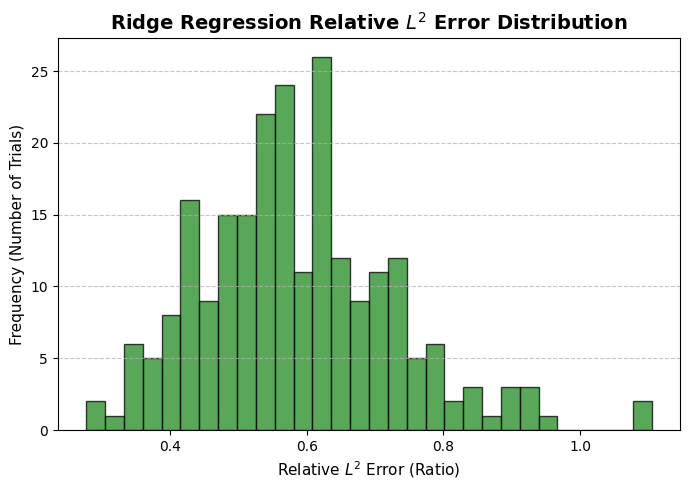

In [36]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# ==========================================
# 13. RIDGE REGRESSION: QUANTITATIVE EVALUATION ON TEST SET
# ==========================================

# Estraiamo i dati dal test_loader per garantire un confronto equo
X_test_list, y_test_list = [], []
for x_batch, y_batch in test_loader:
    X_test_list.append(x_batch.numpy())
    y_test_list.append(y_batch.numpy())

X_test_arr = np.concatenate(X_test_list, axis=0)
y_test_arr = np.concatenate(y_test_list, axis=0)

N_test, T_test, F_test = X_test_arr.shape

# Appiattiamo per l'inferenza
X_test_flat = X_test_arr.reshape(-1, F_test)
y_test_flat = y_test_arr.reshape(-1, 2)

# --- INFERENZA ---
ridge_pred_flat = ridge_model.predict(X_test_flat)

# Calcolo dell'R2
ridge_r2_x = r2_score(y_test_flat[:, 0], ridge_pred_flat[:, 0])
ridge_r2_y = r2_score(y_test_flat[:, 1], ridge_pred_flat[:, 1])
ridge_r2_global = r2_score(y_test_flat, ridge_pred_flat)

# Ripristiniamo la shape 3D (Trial, Time, Kinematics) per calcolare l'errore L2 per trial
ridge_pred_arr = ridge_pred_flat.reshape(N_test, T_test, 2)

# Calcolo del Relative L2 Error (usando tensori PyTorch per mantenere la stessa logica matematica)
pred_tensor = torch.Tensor(ridge_pred_arr)
true_tensor = torch.Tensor(y_test_arr)

diff_norm = torch.linalg.norm((pred_tensor - true_tensor).reshape(N_test, -1), dim=1)
true_norm = torch.linalg.norm(true_tensor.reshape(N_test, -1), dim=1)
ridge_rel_l2_errors = (diff_norm / true_norm).numpy()

# --- STAMPA RISULTATI ---
print("=== RIDGE BENCHMARK TEST SET RESULTS ===")
print(f"Global R2 Score:       {ridge_r2_global:.4f}")
print(f"X Velocity R2:         {ridge_r2_x:.4f}")
print(f"Y Velocity R2:         {ridge_r2_y:.4f}")
print(f"Relative L2 Error:     {np.mean(ridge_rel_l2_errors):.4f} ± {np.std(ridge_rel_l2_errors):.4f}")
print(f"Median Rel L2 Error:   {np.median(ridge_rel_l2_errors):.4f}")
print("========================================\n")

# --- PLOT ISTOGRAMMA ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(ridge_rel_l2_errors, bins=30, color='forestgreen', edgecolor='black', alpha=0.75)
ax.set_title('Ridge Regression Relative $L^2$ Error Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Relative $L^2$ Error (Ratio)', fontsize=11)
ax.set_ylabel('Frequency (Number of Trials)', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Generating nested grid plot for 3 condition(s) using Ridge Regression.


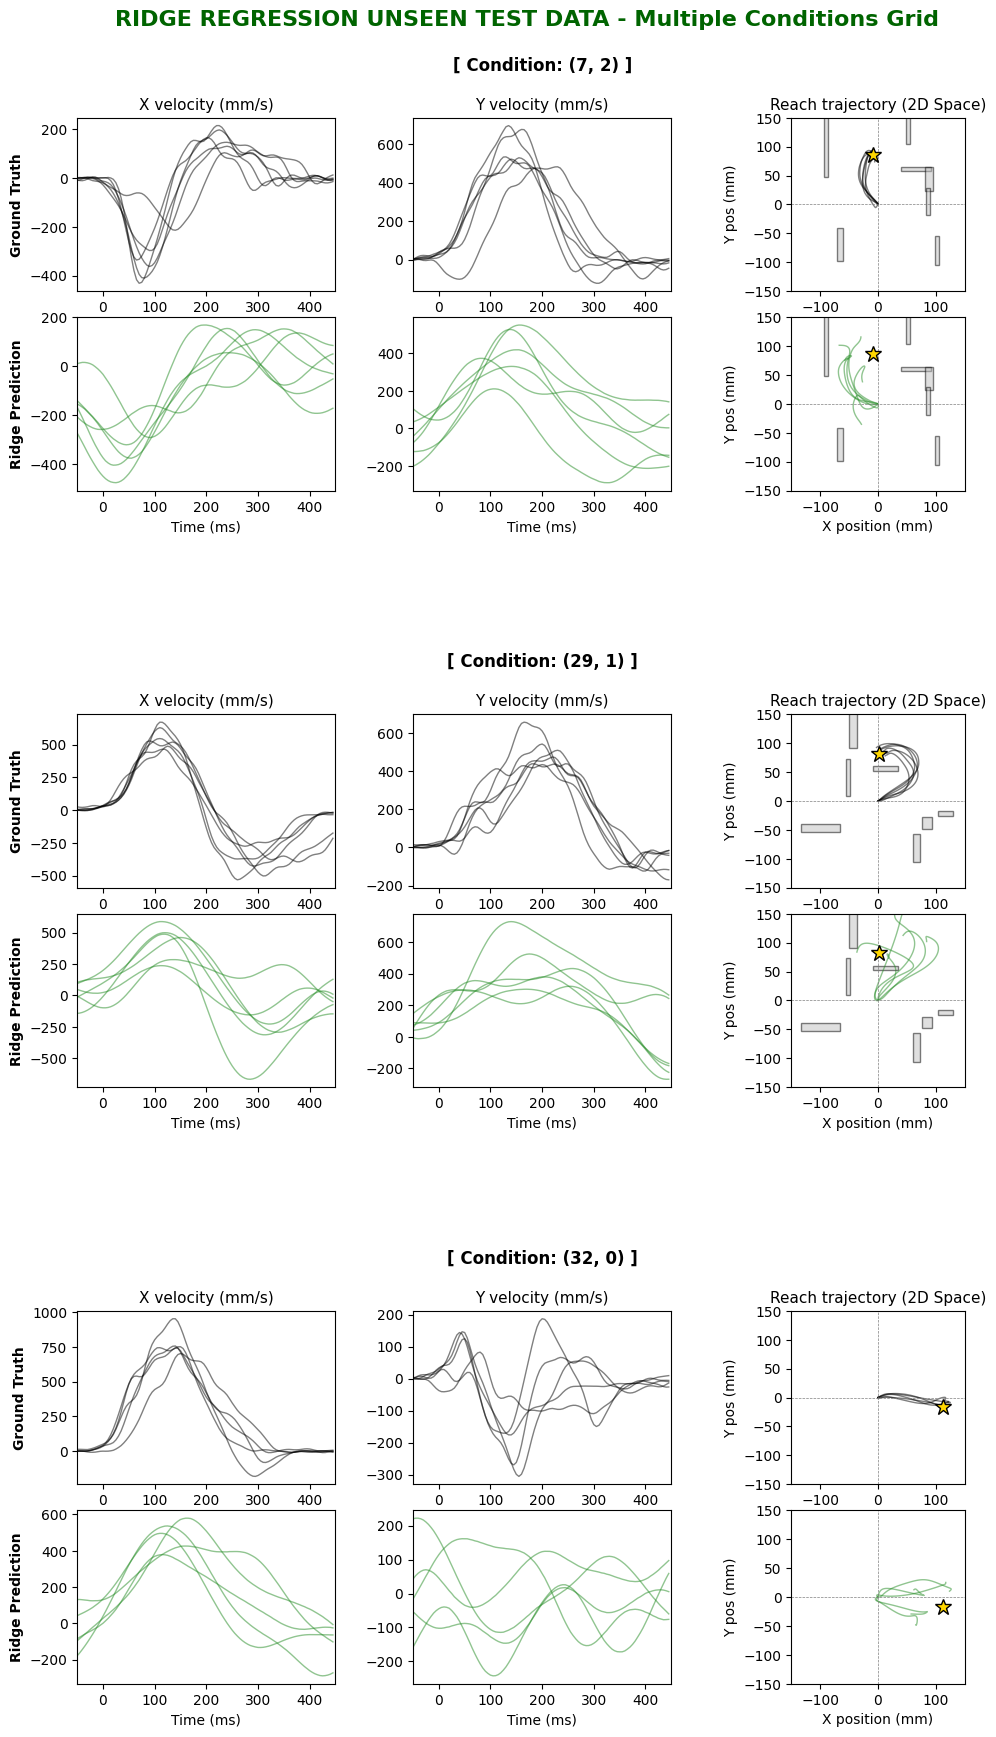

In [38]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np

# ==========================================
# 14. RIDGE REGRESSION VISUALIZATION: KINEMATIC GRID PLOT
# ==========================================

# 1. Identify conditions using the globally available test_trial_ids
test_info = dataset.trial_info.loc[test_trial_ids]
available_conds = test_info.value_counts(['trial_type', 'trial_version']).index.tolist()

# Define the indices of the conditions you want to plot (same as FNO/LSTM)
condition_indices = [0, 1, 2]  
valid_indices = [idx for idx in condition_indices if idx < len(available_conds)]

if not valid_indices:
    print("Error: All provided indices are out of bounds.")
else:
    n_conds = len(valid_indices)
    print(f"Generating nested grid plot for {n_conds} condition(s) using Ridge Regression.")

    fig = plt.figure(figsize=(12, 6 * n_conds))
    # Note: Ridge retains darkgreen title color
    fig.suptitle('RIDGE REGRESSION UNSEEN TEST DATA - Multiple Conditions Grid', 
                 fontsize=16, fontweight='bold', color='darkgreen', y=0.98)

    outer_gs = gridspec.GridSpec(n_conds, 1, figure=fig, hspace=0.6, top=0.92, bottom=0.05)

    t_dynamic = np.linspace(-50, 450, n_time_bins, endpoint=False)
    dt_seconds = (500.0 / n_time_bins) / 1000.0

    for i, c_idx in enumerate(valid_indices):
        cond = available_conds[c_idx]
        
        inner_gs = outer_gs[i].subgridspec(2, 3, hspace=0.15, wspace=0.3)
        axs = np.empty((2, 3), dtype=object)
        for r in range(2):
            for c in range(3):
                axs[r, c] = fig.add_subplot(inner_gs[r, c])
        
        cond_trials_in_test = test_info[
            (test_info['trial_type'] == cond[0]) & 
            (test_info['trial_version'] == cond[1])
        ].index.tolist()

        # --- Extract first trial info for maze geometry ---
        first_trial_info = test_info.loc[cond_trials_in_test[0]]

        # --- Draw Maze and Target on the Spatial Plots (Column 2) ---
        for r in range(2):
            if 'barrier_pos' in first_trial_info and first_trial_info['barrier_pos'] is not None:
                for barrier in first_trial_info['barrier_pos']:
                    # Format is [x_bottom_left, y_bottom_left, width, height]
                    x_bl, y_bl, w, h = barrier
                    rect = patches.Rectangle((x_bl, y_bl), w, h,
                                             linewidth=1, edgecolor='black', facecolor='silver', alpha=0.5)
                    axs[r, 2].add_patch(rect)

            if 'target_pos' in first_trial_info and first_trial_info['target_pos'] is not None:
                active_target_idx = first_trial_info['active_target']
                target = first_trial_info['target_pos'][active_target_idx]
                # Manteniamo la stella ma le diamo un colore ambra visibile
                axs[r, 2].plot(target[0], target[1], marker='*', markersize=12, color='gold', markeredgecolor='black', zorder=10)

        for t_id in cond_trials_in_test:
            # Find the index safely using the globally tracked unique_trial_ids
            idx = np.where(unique_trial_ids == t_id)[0][0]
            
            true_v = vel_3d[idx] 
            true_vx = true_v[:, 0]
            true_vy = true_v[:, 1]
            
            # --- RIDGE INFERENCE ---
            rates_input = rates_3d[idx] # Scikit-learn si aspetta un input 2D (Time, Neurons)
            pred_v = ridge_model.predict(rates_input) 
            pred_vx = pred_v[:, 0]
            pred_vy = pred_v[:, 1]
            
            axs[0, 0].plot(t_dynamic, true_vx, linewidth=1, color='black', alpha=0.5)
            # Ridge retains forestgreen prediction color
            axs[1, 0].plot(t_dynamic, pred_vx, linewidth=1, color='forestgreen', alpha=0.5)
            
            axs[0, 1].plot(t_dynamic, true_vy, linewidth=1, color='black', alpha=0.5)
            axs[1, 1].plot(t_dynamic, pred_vy, linewidth=1, color='forestgreen', alpha=0.5)
            
            true_traj = np.cumsum(true_v, axis=0) * dt_seconds
            pred_traj = np.cumsum(pred_v, axis=0) * dt_seconds
            
            axs[0, 2].plot(true_traj[:, 0], true_traj[:, 1], linewidth=1, color='black', alpha=0.5)
            axs[1, 2].plot(pred_traj[:, 0], pred_traj[:, 1], linewidth=1, color='forestgreen', alpha=0.5)

        # Formatting
        for r in range(2):
            axs[r, 0].set_xlim(-50, 450)
            axs[r, 1].set_xlim(-50, 450)
            axs[r, 2].set_xlim(-150, 150)
            axs[r, 2].set_ylim(-150, 150)
            axs[r, 2].axhline(0, color='grey', linestyle='--', linewidth=0.5)
            axs[r, 2].axvline(0, color='grey', linestyle='--', linewidth=0.5)

            # Ensure Maze Geometry is not Distorted
            axs[r, 2].set_aspect('equal')
            
            if r == 0:
                axs[r, 0].set_ylabel('Ground Truth', fontweight='bold', fontsize=10)
            else:
                axs[r, 0].set_ylabel('Ridge Prediction', fontweight='bold', fontsize=10)

        # Titles
        axs[0, 1].annotate(f'[ Condition: {cond} ]', xy=(0.5, 1.25), 
                           xycoords='axes fraction', ha='center', va='bottom', 
                           fontsize=12, fontweight='bold')
        
        axs[0, 0].set_title('X velocity (mm/s)', fontsize=11, fontweight='normal')
        axs[0, 1].set_title('Y velocity (mm/s)', fontsize=11, fontweight='normal')
        axs[0, 2].set_title('Reach trajectory (2D Space)', fontsize=11, fontweight='normal')

        axs[1, 0].set_xlabel('Time (ms)')
        axs[1, 1].set_xlabel('Time (ms)')
        axs[1, 2].set_xlabel('X position (mm)')
        
        axs[0, 2].set_ylabel('Y pos (mm)')
        axs[1, 2].set_ylabel('Y pos (mm)')

    plt.show()